In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


# Load files and compute metrics

In [2]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
label_rmet_lat = [r"$\frac{RB(\pi_E)_{Roman+Rubin}}{RB(\pi_E)_{Roman}}$", r"$\frac{SB(\pi_E)_{Roman+Rubin}}{SB(\pi_E)_{Roman}}$", 
                 r"$\frac{NU(\pi_E)_{Roman+Rubin}}{NU(\pi_E)_{Roman}}$"]
param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

labelsparams = lambda p: labels[p]
label_m3 = lambda p :r'$\frac{\sigma_{'+f'{labels[p]}'+'}}{'+f'{labels[p]}'+'^{fit}}$'#+f'{labels[p]}'+'}}$'
label_m2 = lambda p :r'$\frac{|'+f'{labels[p]}'+'^{true}-'+f'{labels[p]}'+'^{fit}|}{\sigma_{'+f'{labels[p]}'+'}}$'

In [3]:
import pyarrow.dataset as ds

model = 'USBL'
system_type = "PB"

if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]

true = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/true_{system_type}.parquet")
fit_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/fit_rr_{system_type}.parquet")
fit_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/fit_roman_{system_type}.parquet")
data = "rr"
met_1_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_1_{data}_{system_type}.parquet")
met_2_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_2_{data}_{system_type}.parquet")
met_3_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_3_{data}_{system_type}.parquet")

data = "roman"
met_1_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_1_{data}_{system_type}.parquet")
met_2_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_2_{data}_{system_type}.parquet")
met_3_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_3_{data}_{system_type}.parquet")

del data

met1_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met1_ratio_{system_type}.parquet")
met2_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met2_ratio_{system_type}.parquet")
met3_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met3_ratio_{system_type}.parquet")


# Plots

## True parameters as distributions

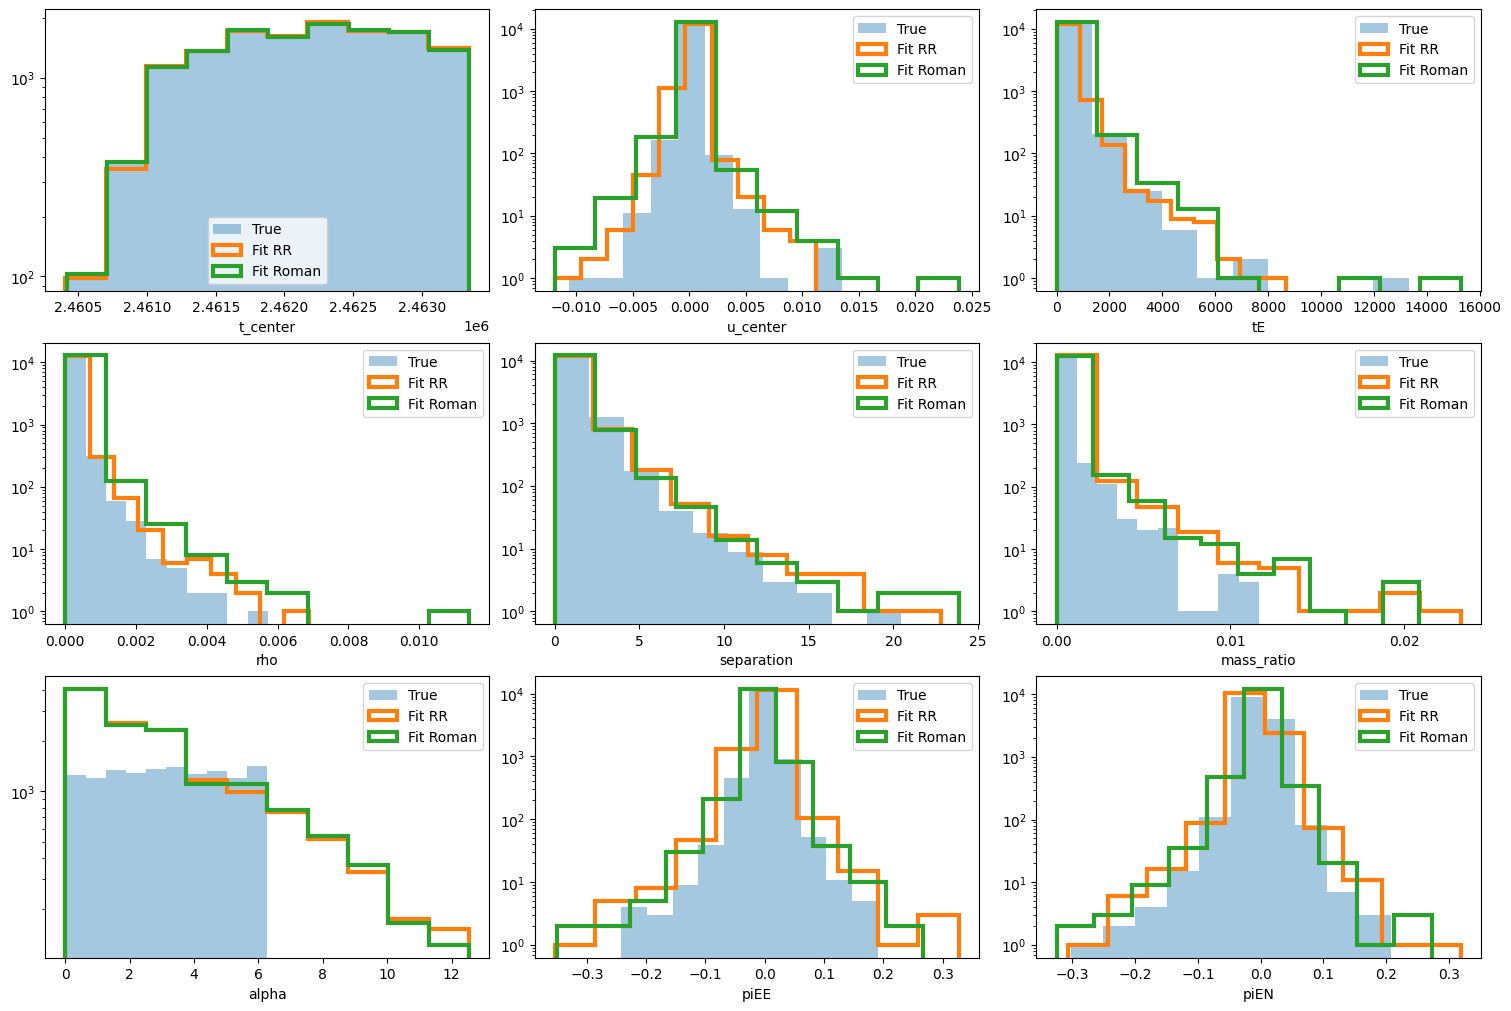

In [4]:
params = ['t_center', 'u_center', 'tE', 'rho', 'separation', 'mass_ratio', 'alpha', 'piEE', 'piEN']

# Create subplots
n_rows = 3  # Number of rows in the grid
n_cols = 3  # Number of columns in the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through parameters and corresponding axes
for i, p in enumerate(params):
    ax = axes[i]
    ax.hist(true[p], alpha=0.4, label='True')
    ax.hist(fit_rr[p], histtype='step', lw=3, label='Fit RR')
    ax.hist(fit_roman[p], histtype='step', lw=3, label='Fit Roman')
    if p =='mass_ratio':
        ax.set_xticks([0,0.01,0.02])
    ax.set_yscale('log')
    ax.set_xlabel(p)
    ax.legend()

# Remove empty subplots (if any)
for i in range(len(params), len(axes)):
    fig.delaxes(axes[i])

# Show the final grid of histograms
plt.show()


## Estimated values

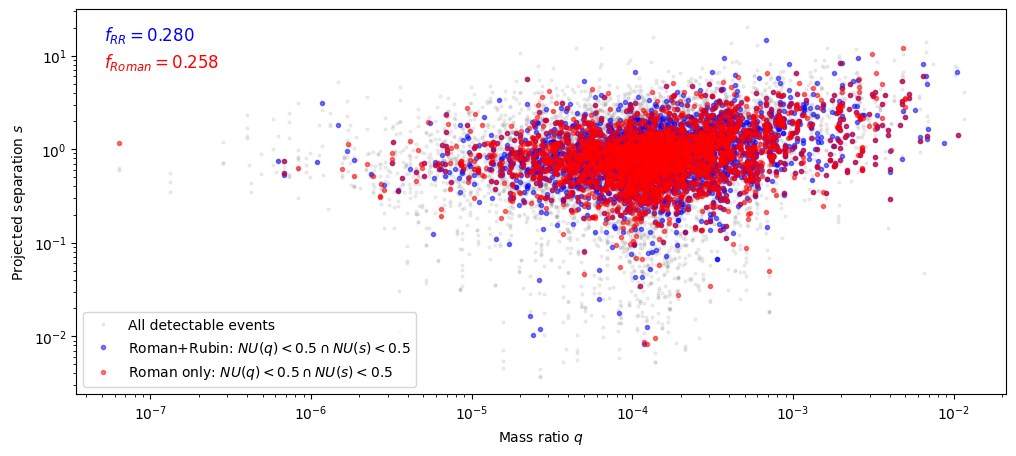

In [5]:
def plot_qs_recovered(true, met_rr, met_roman, ax):

    met_rr_small = met_rr[["Set", "Source", "mass_ratio", "separation"]].rename(columns={
        "mass_ratio": "NU_q_rr",
        "separation": "NU_s_rr"
    })

    met_roman_small = met_roman[["Set", "Source", "mass_ratio", "separation"]].rename(columns={
        "mass_ratio": "NU_q_roman",
        "separation": "NU_s_roman"
    })

    true_rr = true.merge(met_rr_small, on=["Set", "Source"], how="inner", validate="one_to_one")
    true_roman = true.merge(met_roman_small, on=["Set", "Source"], how="inner", validate="one_to_one")

    mask_rr = (true_rr["NU_q_rr"] < 0.5) & (true_rr["NU_s_rr"] < 0.5)
    mask_roman = (true_roman["NU_q_roman"] < 0.5) & (true_roman["NU_s_roman"] < 0.5)

    # número total de eventos detectables
    N_tot = len(true)

    f_rr = mask_rr.sum() / N_tot
    f_roman = mask_roman.sum() / N_tot

    # puntos
    ax.plot(
        true["mass_ratio"], true["separation"],
        "o", color="grey", alpha=0.12, markersize=2,
        label="All detectable events"
    )

    ax.plot(
        true_rr.loc[mask_rr, "mass_ratio"],
        true_rr.loc[mask_rr, "separation"],
        "o", color="blue", alpha=0.5, markersize=3,
        label=r"Roman+Rubin: $NU(q)<0.5 \cap NU(s)<0.5$"
    )

    ax.plot(
        true_roman.loc[mask_roman, "mass_ratio"],
        true_roman.loc[mask_roman, "separation"],
        "o", color="red", alpha=0.5, markersize=3,
        label=r"Roman only: $NU(q)<0.5 \cap NU(s)<0.5$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Mass ratio $q$")
    ax.set_ylabel(r"Projected separation $s$")

    ax.legend()

    # anotaciones con fracciones
    ax.annotate(
        rf"$f_{{RR}} = {f_rr:.3f}$",
        xy=(0.03, 0.92),
        xycoords="axes fraction",
        color="blue",
        fontsize=12
    )

    ax.annotate(
        rf"$f_{{Roman}} = {f_roman:.3f}$",
        xy=(0.03, 0.85),
        xycoords="axes fraction",
        color="red",
        fontsize=12
    )

fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1]})

plot_qs_recovered(true, met_3_rr, met_3_roman, ax)
plt.savefig("/home/anibal-pc/qs_constrained.png")

### Functions to create plots

In [6]:
def create_hist2d_with_marginals(ax, x, y, labels, p, first_col=False):

    tex_label = {'t0':'t_0', 'u0':'u_0', 'te':'t_E','rho':'\\rho', 's':'s', 'q':'q', 'alpha':'\\alpha', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}
    # Main scatter plot
    hb = ax.hist2d(x, y, bins=(np.arange(0, 1.9, 0.1), np.arange(0, 1.9, 0.1)), cmap='Greens')
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)

    # Create inset axes for the histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)

    # Histogram settings
    binwidth = 0.1
    ax_histx.hist(x, bins=np.arange(0, 1.8, binwidth), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='red')
    ax_histy.hist(y, bins=np.arange(0, 1.8, binwidth), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')

    # Remove ticks from inset histograms
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histx.tick_params(axis="y", left=False, labelleft=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
    # ax_histy.set_yscale("log")
    # Add vertical and horizontal lines
    ax_histx.axvline(1, color='red', ls='--')
    ax_histy.axhline(1, color='red', ls='--')
    ax.axvline(1, ymin=0, ymax=0.5, lw=2, color='red')
    ax.axvline(0, ymin=0, ymax=0.5, lw=2, color='red')
    ax.axhline(0, xmin=0, xmax=0.5, lw=2, color='red')
    ax.axhline(1, xmin=0, xmax=0.5, lw=2, color='red')

    # Set labels with LaTeX formatting
    # label_m1 = lambda p: r'$\frac{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{RR}}{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{R}}$'
    # label_m2 = r'$\frac{\sigma_{RR}}{\sigma_{Roman}}$'
    labelx, labely =labels[0],labels[1]
    ax.set_xlabel(labelx, fontsize=20)
    
    # ax.set_xlabel("a",fontsize=20)
    # if first_col:
    ax.set_ylabel(labely, fontsize=20)

    # Add a colorbar inside the main plot
    cax = ax.inset_axes([0.85, 0.05, 0.03, 0.35], transform=ax.transAxes)
    cbar = plt.colorbar(hb[3], cax=cax, orientation='vertical')
    # cax.set_yticks([0, 50, 1000])
    # cax.set_yticklabels([0, 100, 2000], fontsize=8)
    x_min=0
    x_max=1
    y_min=0
    y_max=1
    fil_x= x[(y<1)&(y>0)]
    filtered=fil_x[(fil_x<1)&(fil_x>0)]

    number_in_square = len(filtered)/len(y)
    text = f"Fraction of events\n in [{x_min},{x_max}] x [{y_min},{y_max}]= {round(number_in_square ,2)}"  # Insert the number here
    ax.set_title(text, fontsize = 16)


def plot_histogram(ax, DATA, p, colors, some_flag=False):
    # print(data)
    sources = DATA['Source'].values
    data = DATA[p]   
    lab_latex = {'tE':'tE(days)','rho':'\\rho' ,'piE':'\pi_E','mass_ratio':'q'}
    data_label = lab_latex[p]
    lab_latex_legend = {'tE':'t_E','rho':'\\rho','piE':'\pi_E','mass_ratio':'q'}
    xlabel=r'$log_{10}'+f"[{lab_latex[p]}]$"
    
    masks_rr = lambda p, label: [
        (met_1_rr[p][met_1_rr['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_rr[p][met_2_rr['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_rr[p][met_3_rr['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    masks_roman = lambda p, label:[
        (met_1_roman[p][met_1_roman['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_roman[p][met_2_roman['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_roman[p][met_3_roman['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    
    if some_flag:
        masks = masks_roman(p,lab_latex_legend[p])
        dataset = 'Roman'
        met_1 = met_1_roman[met_1_roman['Source'].isin(sources)]
        met_2 = met_2_roman[met_2_roman['Source'].isin(sources)]
        met_3 = met_3_roman[met_3_roman['Source'].isin(sources)]
    else:
        masks = masks_rr(p,lab_latex_legend[p])
        dataset = 'Roman and Rubin'
        met_1 = met_1_rr[met_1_rr['Source'].isin(sources)]
        met_2 = met_2_rr[met_2_rr['Source'].isin(sources)]
        met_3 = met_3_rr[met_3_rr['Source'].isin(sources)]

    # Plot the histogram of the true values
    ax.hist(np.log10(data), bins=30, color='royalblue', alpha=0.5, label=f'True value of ${lab_latex_legend[p]}$')
    
    # Iterate over the masks and plot the masked data

    for (mask, color, label) in masks:
        mask = mask.reindex(data.index, fill_value=False)
        
        masked_data = data[mask]
        ax.hist(np.log10(masked_data), 
                bins=30, histtype='step', color=color, lw=2, label=label)
    
    # Set labels and title
    # print(xlabel)


    ax.set_xlabel(xlabel, fontsize=20)
    
    ax.set_title('Percentage of events with:\n'+
                 f"$\\alpha({lab_latex_legend[p]})<0.25: $"+
                 f"{round(100*len(met_1[p][met_1[p]<0.25])/len(data),2)}%, "+'\n'+
                 f"$\\beta({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_2[p][met_2[p]<0.25])/len(data),1)}%, "+'\n'+
                 f"$\\gamma({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_3[p][met_3[p]<0.25])/len(data),2)}%",fontsize=15)
    ax.legend(fontsize=10)
    # ax.set_xticks([1,2,3,4],fontsize=12)
    
    ax.grid()

import numpy as np
import pandas as pd


def plot_histogram(
    ax,
    DATA,
    p_cond,
    p_plot=None,
    some_flag=False,
    threshold=0.25,
    bins=30,
    logx=True
):
    """
    Grafica la distribución de `p_plot` para los eventos contenidos en DATA,
    y superpone las distribuciones de aquellos eventos que satisfacen
    alpha(p_cond) < threshold, beta(p_cond) < threshold, gamma(p_cond) < threshold.

    Parámetros
    ----------
    ax : matplotlib.axes.Axes
        Eje donde se grafica.
    DATA : pandas.DataFrame
        DataFrame con al menos columnas ['Source', 'Set', ...].
        Debe contener el parámetro a graficar `p_plot`.
    p_cond : str
        Parámetro sobre el que se impone la condición en las métricas
        (por ejemplo: 'piE', 'rho', 'tE', 'mass_ratio', etc.).
    p_plot : str or None, optional
        Parámetro cuya distribución se grafica.
        Si es None, se usa p_cond.
        Ejemplo: p_cond='piE' y p_plot='mass_ratio' para graficar q
        de los eventos que satisfacen la condición sobre piE.
    some_flag : bool, optional
        Si True usa Roman. Si False usa Roman+Rubin.
    threshold : float, optional
        Umbral de la condición, por defecto 0.25.
    bins : int, optional
        Número de bins del histograma.
    logx : bool, optional
        Si True grafica log10 del parámetro `p_plot`.
    """

    # ============================================================
    # [NUEVO BLOQUE 1] Definir qué parámetro se grafica
    # ============================================================
    if p_plot is None:
        p_plot = p_cond

    # ============================================================
    # [NUEVO BLOQUE 2] Labels más generales
    # ============================================================
    lab_latex = {
        'tE': r't_E(\mathrm{days})',
        'rho': r'\rho',
        'piE': r'\pi_E',
        'mass_ratio': r'q',
        'q': r'q'
    }

    lab_latex_legend = {
        'tE': r't_E',
        'rho': r'\rho',
        'piE': r'\pi_E',
        'mass_ratio': r'q',
        'q': r'q'
    }

    label_plot = lab_latex.get(p_plot, p_plot)
    label_cond = lab_latex_legend.get(p_cond, p_cond)

    if logx:
        xlabel = rf'$\log_{{10}}[{label_plot}]$'
    else:
        xlabel = rf'${label_plot}$'

    # ============================================================
    # [NUEVO BLOQUE 3] Selección por clave unívoca ("Source","Set")
    # ============================================================
    keys = DATA[['Source', 'Set']].drop_duplicates().copy()

    # chequear que el parámetro a graficar exista en DATA
    if p_plot not in DATA.columns:
        raise KeyError(f"El parámetro '{p_plot}' no está en DATA.columns")

    data_df = DATA[['Source', 'Set', p_plot]].copy()

    # ============================================================
    # [NUEVO BLOQUE 4] Elegir dataset de métricas
    # ============================================================
    if some_flag:
        dataset = 'Roman'
        met_1_full = met_1_roman.copy()
        met_2_full = met_2_roman.copy()
        met_3_full = met_3_roman.copy()
    else:
        dataset = 'Roman and Rubin'
        met_1_full = met_1_rr.copy()
        met_2_full = met_2_rr.copy()
        met_3_full = met_3_rr.copy()

    # ============================================================
    # [NUEVO BLOQUE 5] Filtrar métricas por ("Source","Set")
    # ============================================================
    met_1 = keys.merge(
        met_1_full[['Source', 'Set', p_cond]],
        on=['Source', 'Set'],
        how='left'
    )

    met_2 = keys.merge(
        met_2_full[['Source', 'Set', p_cond]],
        on=['Source', 'Set'],
        how='left'
    )

    met_3 = keys.merge(
        met_3_full[['Source', 'Set', p_cond]],
        on=['Source', 'Set'],
        how='left'
    )

    # ============================================================
    # [NUEVO BLOQUE 6] Unir métrica + variable a graficar
    # ============================================================
    df1 = data_df.merge(
        met_1.rename(columns={p_cond: 'metric_value'}),
        on=['Source', 'Set'],
        how='left'
    )

    df2 = data_df.merge(
        met_2.rename(columns={p_cond: 'metric_value'}),
        on=['Source', 'Set'],
        how='left'
    )

    df3 = data_df.merge(
        met_3.rename(columns={p_cond: 'metric_value'}),
        on=['Source', 'Set'],
        how='left'
    )

    # datos verdaderos a graficar
    data = data_df[p_plot]

    # ============================================================
    # [NUEVO BLOQUE 7] Preparar transformada logarítmica de forma segura
    # ============================================================
    def transform_for_plot(series, use_log=True):
        series = pd.to_numeric(series, errors='coerce')
        if use_log:
            series = series[series > 0]
            return np.log10(series)
        return series.dropna()

    data_plot = transform_for_plot(data, use_log=logx)

    # histograma del valor verdadero
    ax.hist(
        data_plot,
        bins=bins,
        color='royalblue',
        alpha=0.5,
        label=rf'True value of ${label_plot}$'
    )

    # ============================================================
    # [NUEVO BLOQUE 8] Construcción general de máscaras
    # ============================================================
    masked_configs = [
        (df1['metric_value'] < threshold, 'r', rf"$\alpha({label_cond})<{threshold}$", df1),
        (df2['metric_value'] < threshold, 'k', rf"$\beta({label_cond})<{threshold}$", df2),
        (df3['metric_value'] < threshold, 'g', rf"$\gamma({label_cond})<{threshold}$", df3),
    ]

    for mask, color, label, dfm in masked_configs:
        masked_data = transform_for_plot(dfm.loc[mask, p_plot], use_log=logx)
        ax.hist(
            masked_data,
            bins=bins,
            histtype='step',
            color=color,
            lw=2,
            label=label
        )

    # ============================================================
    # [NUEVO BLOQUE 9] Fracciones calculadas con la clave ("Source","Set")
    # ============================================================
    n_total = len(data_df) if len(data_df) > 0 else 1

    frac_1 = 100 * (df1['metric_value'] < threshold).sum() / n_total
    frac_2 = 100 * (df2['metric_value'] < threshold).sum() / n_total
    frac_3 = 100 * (df3['metric_value'] < threshold).sum() / n_total

    # labels
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel('Number of events', fontsize=16)

    ax.set_title(
        f'{dataset}\n'
        + 'Percentage of events with:\n'
        + rf"$\alpha({label_cond})<{threshold}$: {frac_1:.2f}%"+'\n'
        + rf"$\beta({label_cond})<{threshold}$: {frac_2:.2f}%"+'\n'
        + rf"$\gamma({label_cond})<{threshold}$: {frac_3:.2f}%"
        ,
        fontsize=15
    )

    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

## Histograms 2D metrics and metrics ratio

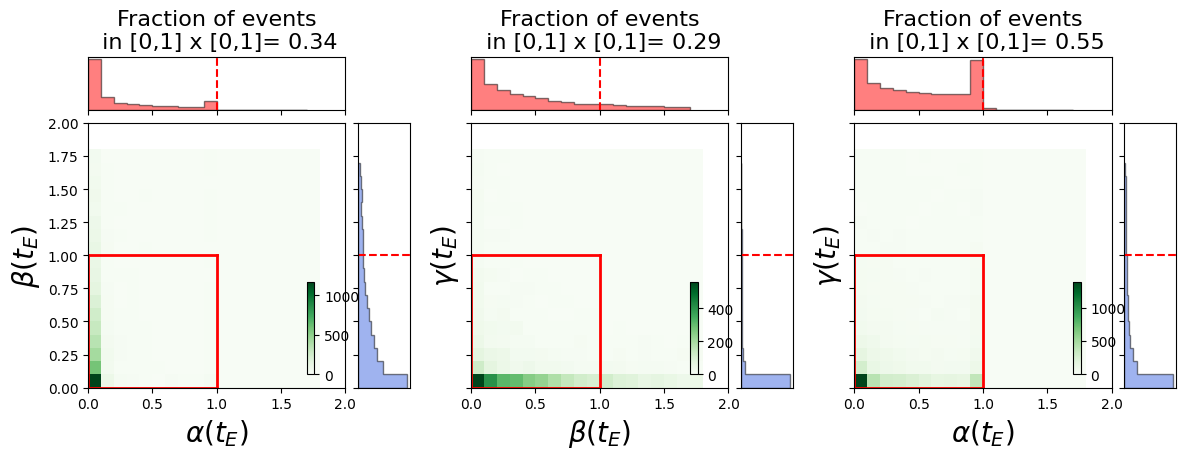

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1,1, 1]})
x = met_1_rr['tE']
y = met_2_rr['tE']
x2 = met_2_rr['tE']
y2 = met_3_rr['tE']
x3 = met_1_rr['piE']
y3 = met_3_rr['piE']
# print(x3)
labels = {'t_center':'t_0', 'u_center':'u_0', 'tE':'t_E','rho':'\\rho', 's':'s', 'q':'q', 'alpha':'\\alpha', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}

p='tE'
create_hist2d_with_marginals(axes[0], x, y, ['$\\alpha$'+f"(${labels[p]}$)",r'$\beta$'+f"(${labels[p]}$)"], p, first_col=True)
create_hist2d_with_marginals(axes[1], x2, y2, ['$\\beta$'+f"(${labels[p]}$)",r'$\gamma$'+f"(${labels[p]}$)"], p)
create_hist2d_with_marginals(axes[2], x3, y3, ['$\\alpha$'+f"(${labels[p]}$)",r'$\gamma$'+f"(${labels[p]}$)"], p)

plt.tight_layout()
plt.show()

## Histograms true parameters and overlap histograms of the estimated parameters from fits

The fraction of events below certain thresholds is included in the graph.

In [8]:
cols = ['Source', 'Set']

df_rr_only = (
    met_3_rr.loc[met_3_rr['piE'] < 0.5, cols]
    .sort_values(['Source', 'Set'])
    .reset_index(drop=True)
)

df_roman_only = (
    met_3_roman.loc[met_3_roman['piE'] < 0.5, cols]
    .sort_values(['Source', 'Set'])
    .reset_index(drop=True)
)



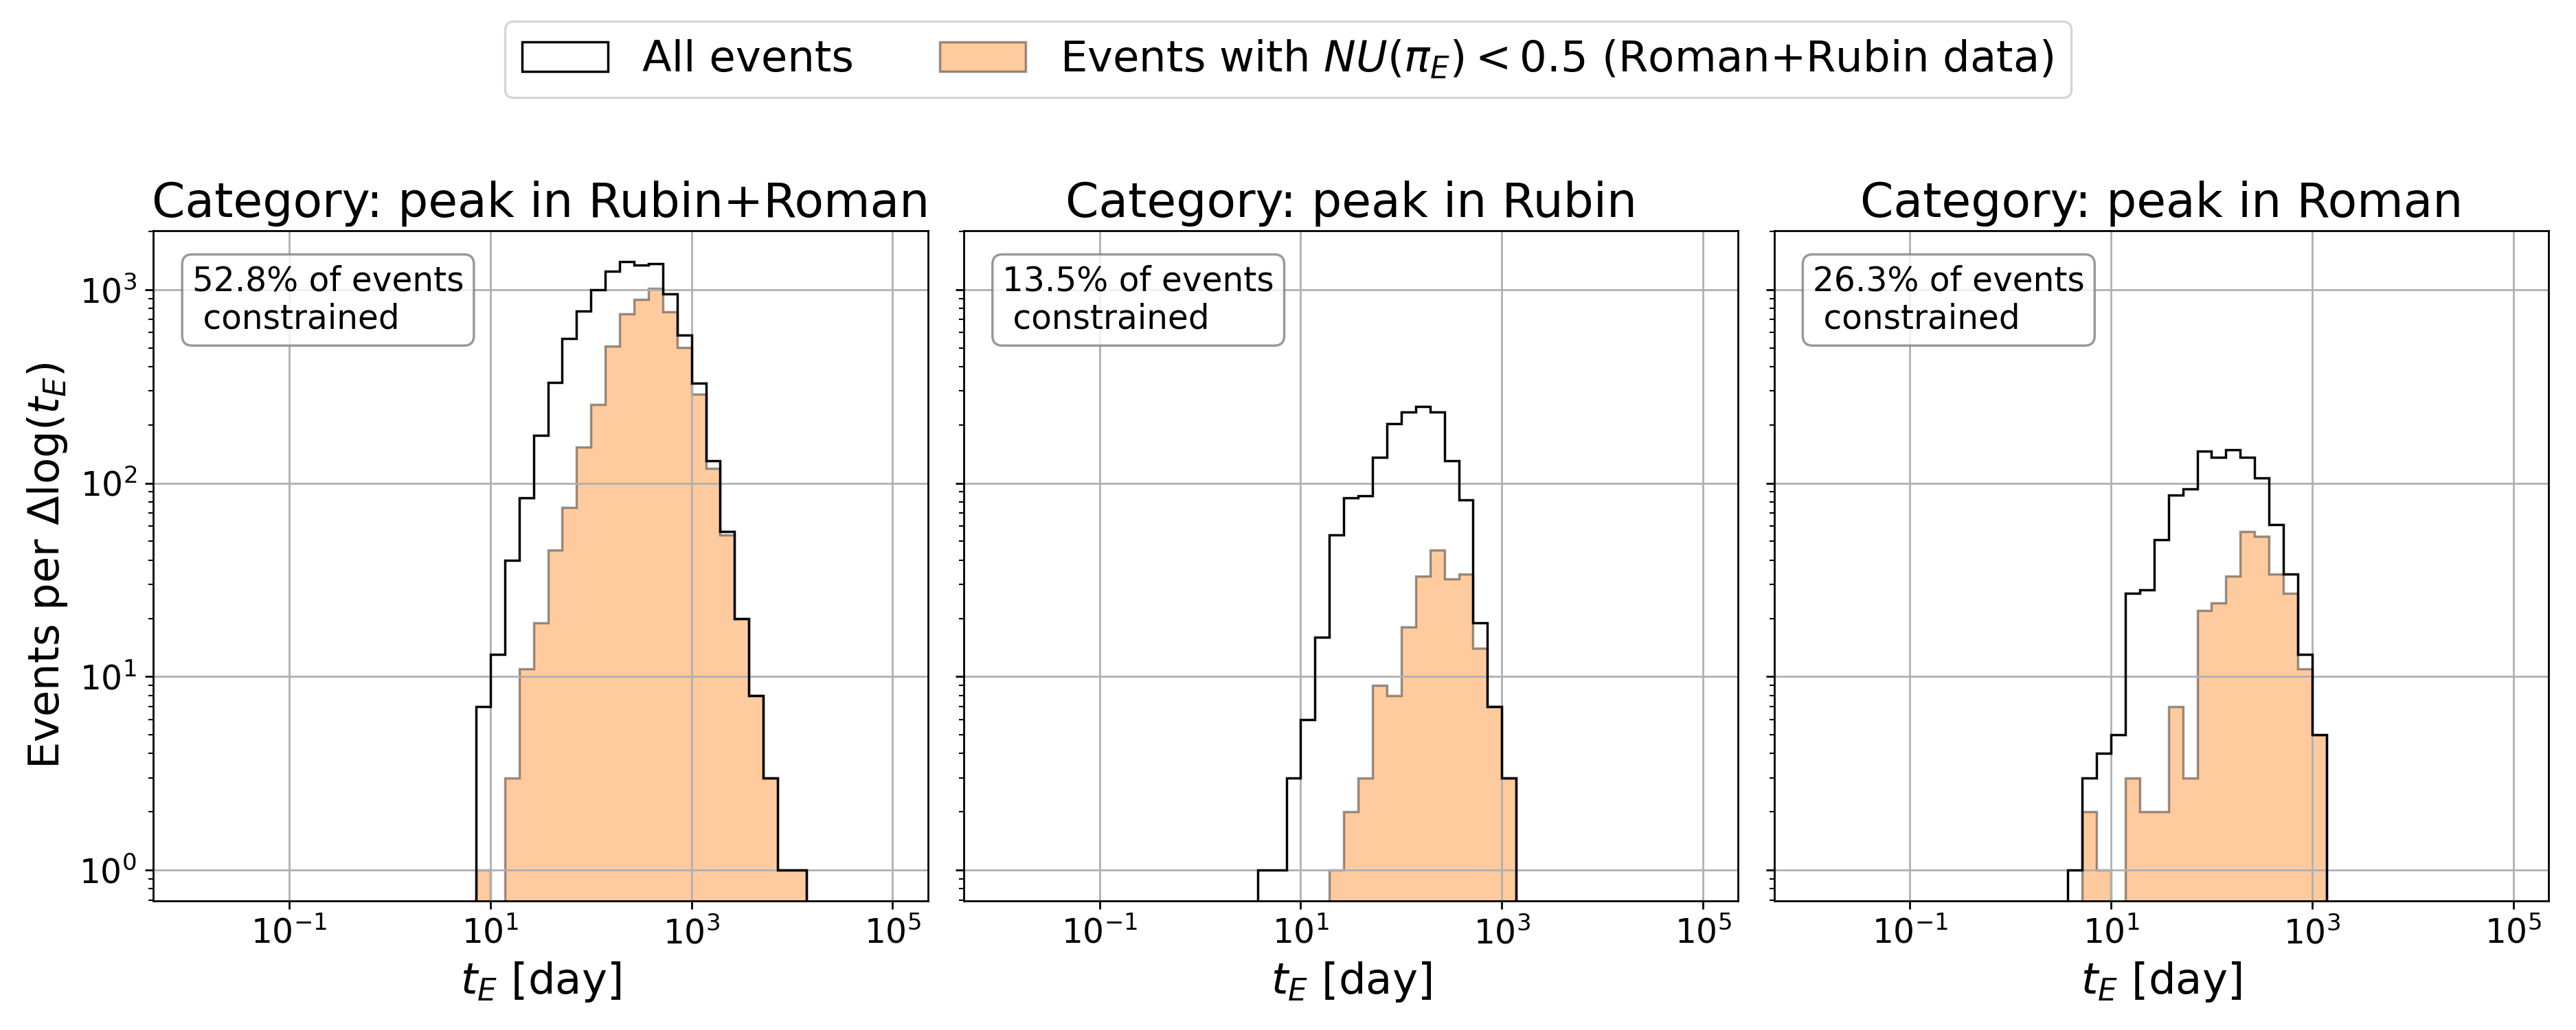

In [14]:
true_filtered_rerror = true.merge(
    df_rr_only,
    on=['Source', 'Set'],
    how='inner'
)
plt.close("all")
p = "tE"
bines  = np.logspace(-2, 5, 50)
hysttype_1 = "step"
hysttype_2 = "stepfilled"

title_new = lambda x: "Category: " + f"{x}"
label2 = "Events with $NU(\pi_E)<0.5$ (Roman+Rubin data)"
label1 = "All events"

categories = ["A", "B", "C"]

fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True, dpi=250)

for ax, cat in zip(axs, categories):

    df1 = true[true["peak_flag"] == cat]
    df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"] == cat]
    
    N_total = len(df1)
    N_subset = len(df2)
    
    if N_total > 0:
        frac = 100 * N_subset / N_total
    else:
        frac = 0.0

    ax.hist(df1[p], bins=bines, histtype=hysttype_1,
            edgecolor='k', label=label1)

    ax.hist(df2[p], bins=bines, histtype=hysttype_2,
            edgecolor='k', alpha=0.4, label=label2)

    ax.annotate(
    f"{frac:.1f}% of events\n constrained",
    xy=(0.05, 0.95),              # posición relativa dentro del eje
    xycoords='axes fraction',
    fontsize=14,
    ha='left',
    va='top',
    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8)
)


    ax.set_title(title_new(dict_cat_peak[cat]), fontsize=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

# Solo el primero lleva ylabel
axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)

# Una sola leyenda
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.85])

# if outdir is None:
outname = "PB_piE<0.5_RR"
outdir = os.getcwd()

png_path = os.path.join(outdir, f"{outname}.png")
pdf_path = os.path.join(outdir, f"{outname}.pdf")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()


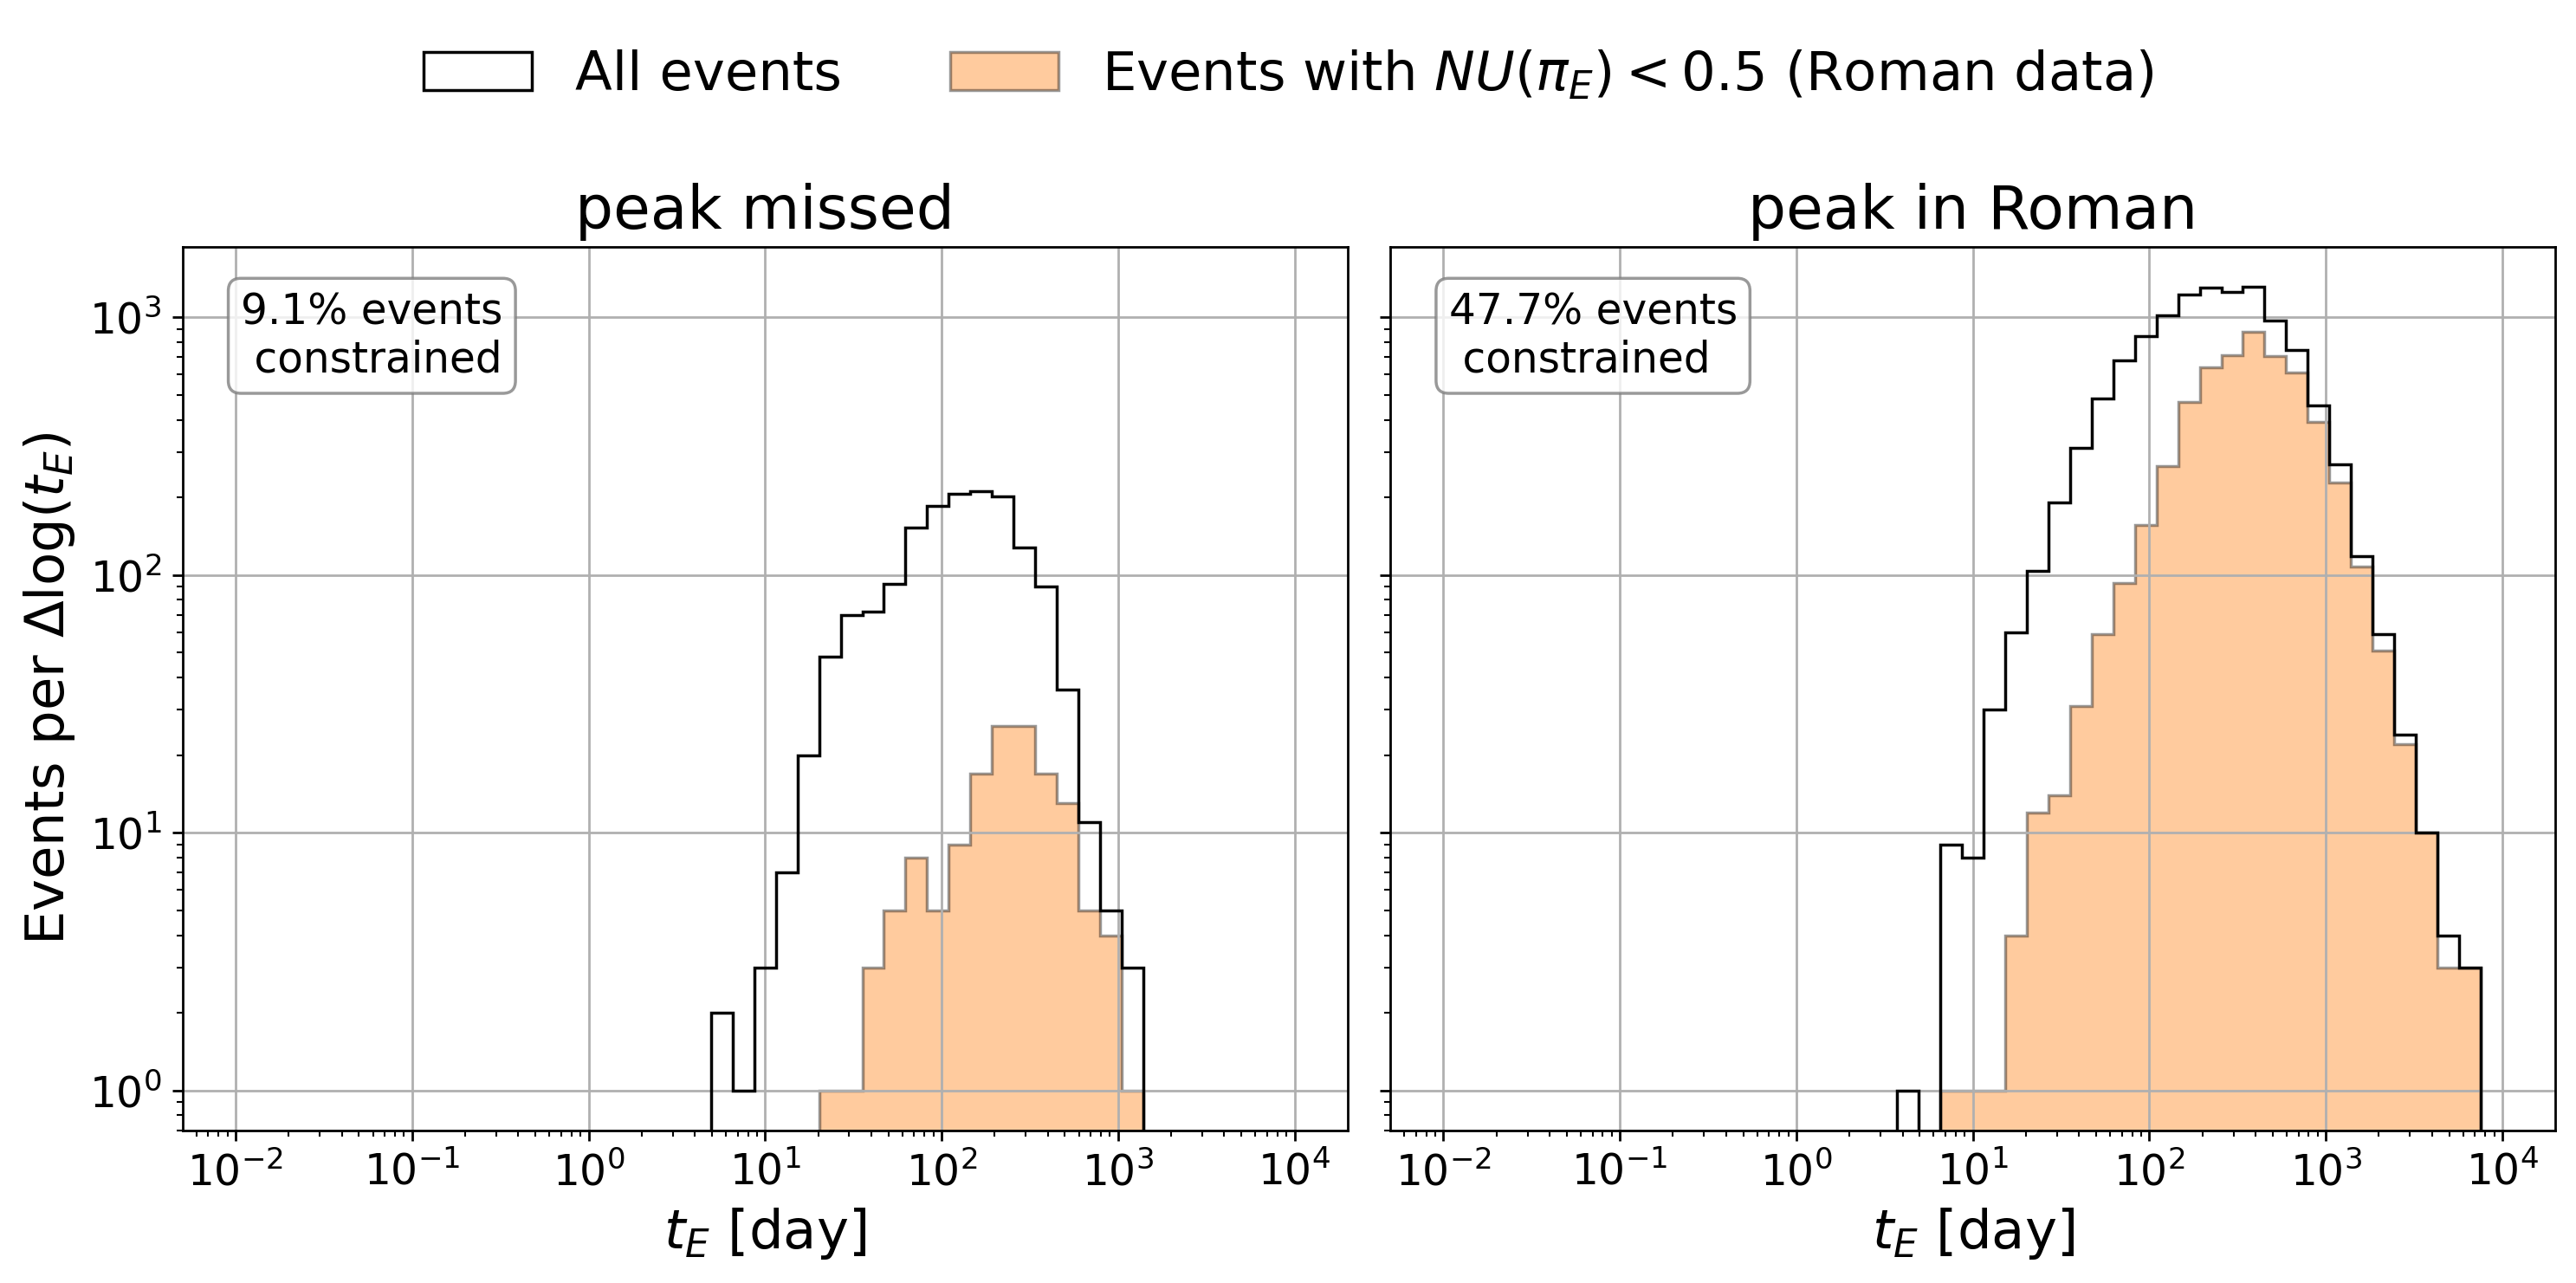

In [10]:
true_filtered_rerror = true.merge(
    df_roman_only,
    on=['Source', 'Set'],
    how='inner'
)
plt.close("all")

p = "tE"
dict_cat_peak_roman = {"A + C":"peak in Roman",
                "B":"peak missed"}
bines  = np.logspace(-2, 4, 50)
hysttype_1 = "step"
hysttype_2 = "stepfilled"

title_new = lambda x: x
label2 = "Events with $NU(\pi_E)<0.5$ (Roman data)"
label1 = "All events"

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True,dpi=250)

# --- Definimos los dos grupos ---
groups = {
    "B": ["B"],
    "A + C": ["A", "C"]
}

for ax, (label_group, cats) in zip(axs, groups.items()):

    df1 = true[true["peak_flag"].isin(cats)]
    df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"].isin(cats)]

    ax.hist(df1[p], bins=bines, histtype=hysttype_1,
            edgecolor='k', label=label1)

    ax.hist(df2[p], bins=bines, histtype=hysttype_2,
            edgecolor='k', alpha=0.4, label=label2)

    # --- porcentaje del subconjunto ---
    N_total = len(df1)
    N_subset = len(df2)
    frac = 100 * N_subset / N_total if N_total > 0 else 0

    ax.annotate(f"{frac:.1f}% events\n constrained",
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=14, ha='left', va='top',
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    ax.set_title(dict_cat_peak_roman[title_new(label_group)], fontsize=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18,frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

outname = "FFP_piE<0.5_Roman"
outdir = os.getcwd()

png_path = os.path.join(outdir, f"{outname}.png")
pdf_path = os.path.join(outdir, f"{outname}.pdf")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()


## Plots less relevants

The file already exist


TypeError: expected str, bytes or os.PathLike object, not NoneType

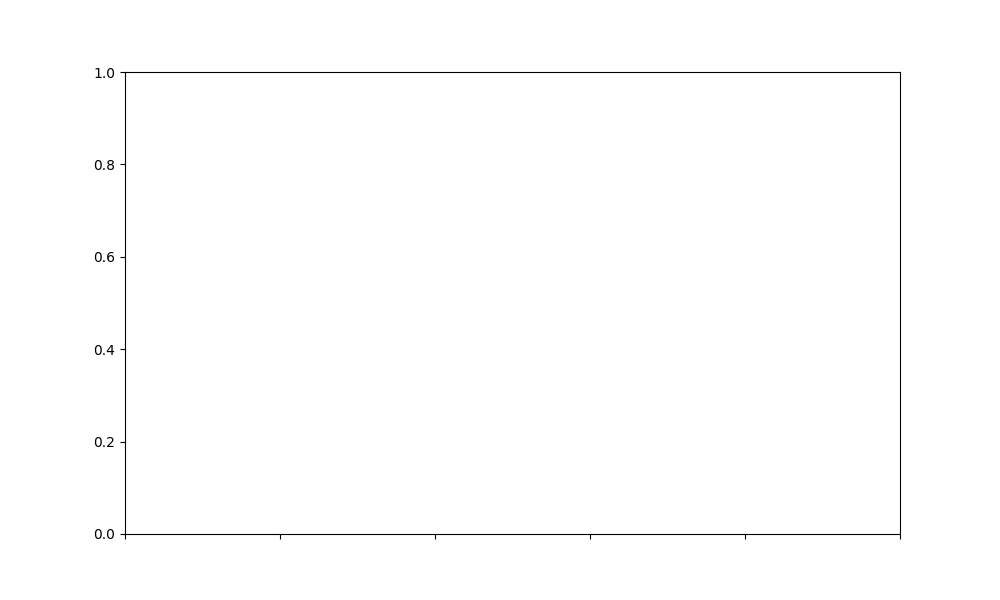

In [15]:
ssh = ssh_che()
#120
sources_array = [1000]
category = 'USBL'

# download_data(sources, category)
nset = 1
path_run = '/share/storage3/rubin/microlensing/romanrubin/RR2025/finalv2_set/Planets_systems/'
system_type = "Planets_systems"
path_save = os.getcwd()+f'/lightcurves/{system_type}_{nset}/'
if not os.path.exists(path_save):
    os.makedirs(path_save, exist_ok=True)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
    download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')


df_to_plot = create_df_to_plot(sources_array, category, path_save)
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

fig, axes = graph_maker_1plot(df_to_plot, category, False)
# info, params, curves  = read_data(df_to_plot['path_event'].iloc[0])
# axes[0].axvspan(params['t_center']-1*params['tE']*np.sqrt(params['mass_ratio']),
#                 params['t_center']+1*params['tE']*np.sqrt(params['mass_ratio']),
#                 alpha=0.15,
#                 color='blue',label="t_{c}\pm t_{Ep}")

# axes[0].axvspan(params['t_center']-5*params['tE']*np.sqrt(params['rho']),params['t_center']+5*params['tE']*np.sqrt(params['rho']),alpha=0.25,color='red')
# plt.tight_layout()
plt.show()

In [ ]:
origin = originclass(params, info[2])
neworigin = origin.new_origin(params)
print(params['u_center'])
print(params['u_center'] - neworigin[0]*np.sin(params['alpha'])+neworigin[1]*np.cos(params['alpha']))
print(1/params['separation']-params['separation'])
